In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

base_dir = "/content/drive/MyDrive/Week - 6/FruitinAmazon"
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

print("Base exists:", os.path.exists(base_dir))
print("Train exists:", os.path.exists(train_dir))
print("Test exists:", os.path.exists(test_dir))

Base exists: False
Train exists: False
Test exists: False


In [5]:
import os

train_dir = "/content/drive/MyDrive/Week - 6/FruitinAmazon/train"

class_names = sorted(
    [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
)

if not class_names:
    print("No class directories found in the train folder!")
else:
    print(f"Found {len(class_names)} classes: {class_names}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


### Task 1

check corrupted images

In [6]:
from PIL import Image, UnidentifiedImageError
import os

train_dir = "/content/drive/MyDrive/Week - 6/FruitinAmazon/train"

class_names = sorted(
    [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
)

corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

if corrupted_images:
    print("Corrupted Images Found:")
    for img in corrupted_images:
        print(img)
else:
    print("No corrupted images found.")

No corrupted images found.


check class balance

In [7]:
import os

train_dir = "/content/drive/MyDrive/Week - 6/FruitinAmazon/train"

class_names = sorted(
    [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
)

class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith((".png", ".jpg", ".jpeg"))
        ]
        class_counts[class_name] = len(images)

print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)

for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")

print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


select one random image from each class

In [8]:
import os
import random

train_dir = "/content/drive/MyDrive/Week - 6/FruitinAmazon/train"

class_names = sorted(
    [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
)

selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith((".png", ".jpg", ".jpeg"))
        ]
        if images:
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

print("Selected labels:", selected_labels)
print("Number of selected images:", len(selected_images))

Selected labels: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of selected images: 6


visualize the selected random images

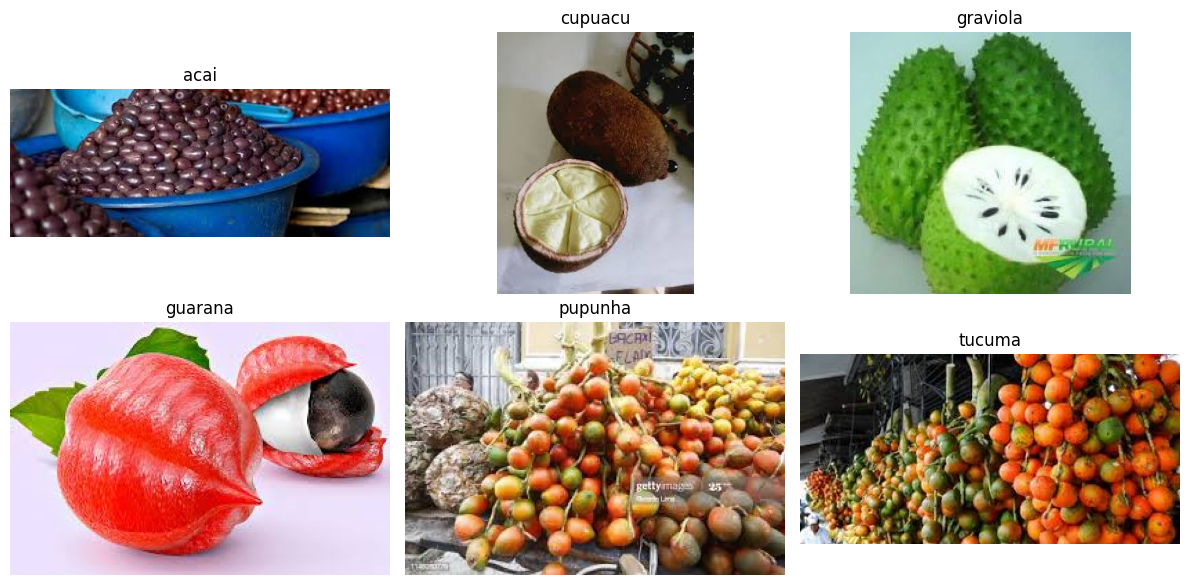

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

num_classes = len(selected_images)
cols = (num_classes + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off")

plt.tight_layout()
plt.show()

create training and validation datasets

In [10]:
import tensorflow as tf
from tensorflow import keras

train_dir = "/content/drive/MyDrive/Week - 6/FruitinAmazon/train"

img_height, img_width = 128, 128
batch_size = 32

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.


check shapes:

In [11]:
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 128, 128, 3)
Labels shape: (32,)


visualize a batch from train_ds

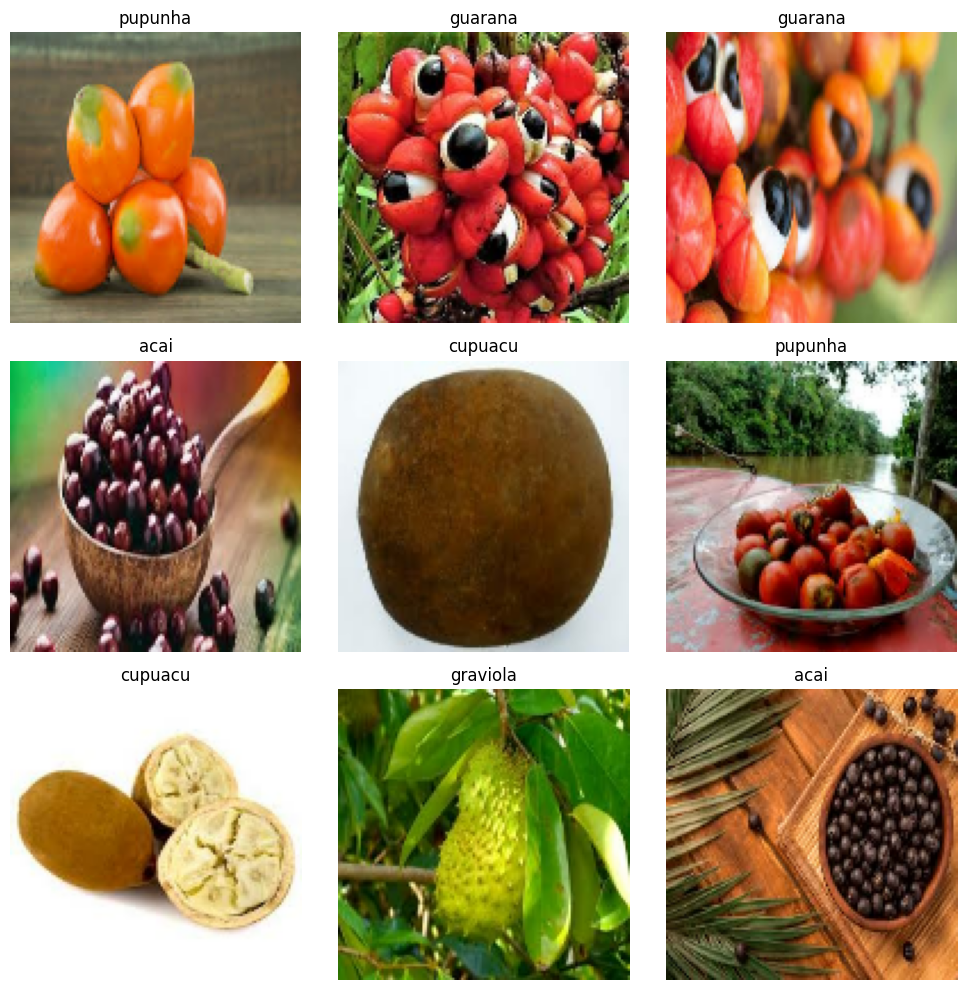

In [12]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

plt.tight_layout()
plt.show()

define data augmentation

In [13]:
from tensorflow import keras
from tensorflow.keras import layers

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
])

print(data_augmentation)

<Sequential name=sequential, built=False>


visualize augmented images

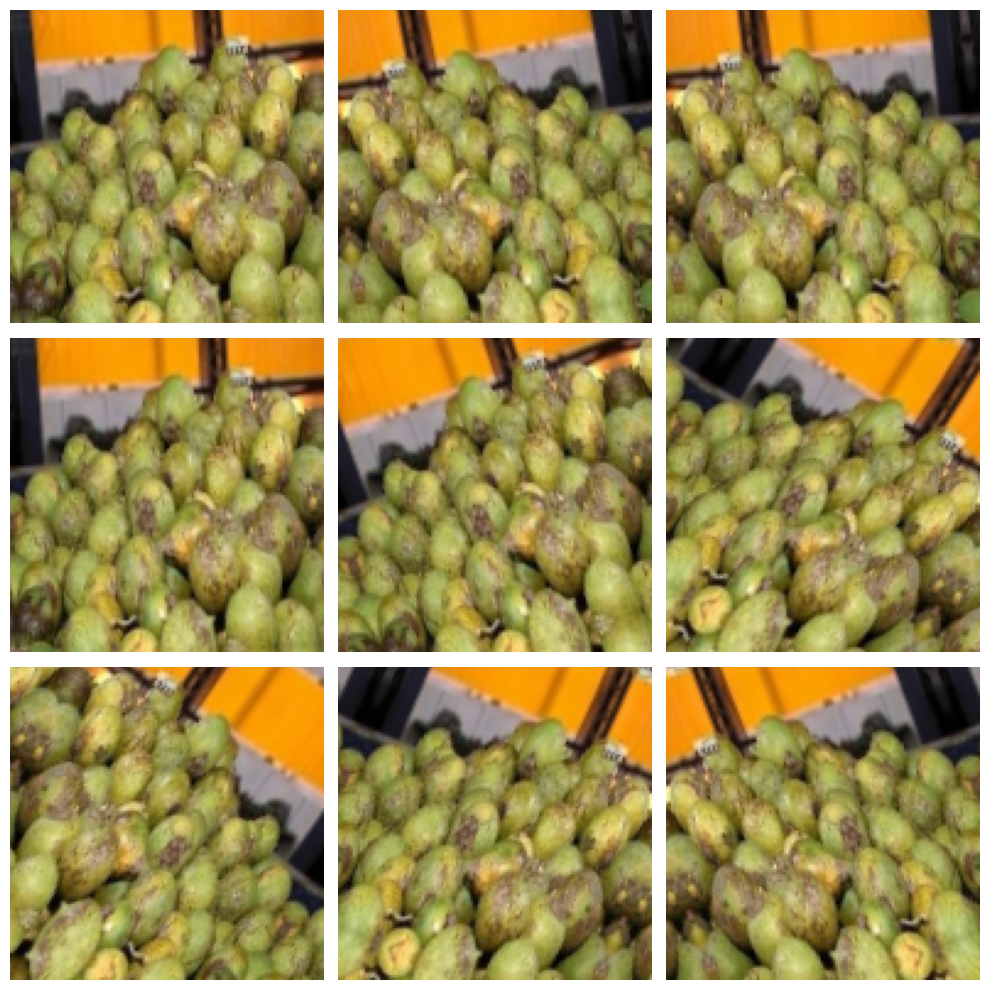

In [14]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 10))

for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented_images[0]).astype("uint8"))
        plt.axis("off")

plt.tight_layout()
plt.show()

build the CNN with BN and Dropout

In [15]:
from tensorflow import keras
from tensorflow.keras import layers

keras.backend.clear_session()

input_shape = (128, 128, 3)

model = keras.Sequential([
    layers.Input(shape=input_shape),
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), padding="same", activation=None),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), padding="same", activation=None),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), padding="same", activation=None),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),

    layers.Dense(128, activation=None),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.5),

    layers.Dense(64, activation=None),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.5),

    layers.Dense(6, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,25

 Total params: 4,297,990 (16.40 MB)

 Trainable params: 4,297,158 (16.39 MB)

 Non-trainable params: 832 (3.25 KB)

train the model

In [16]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.2778 - loss: 2.0082 - val_accuracy: 0.1667 - val_loss: 1.7827
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 738ms/step - accuracy: 0.2917 - loss: 1.8364 - val_accuracy: 0.2222 - val_loss: 1.7682
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 829ms/step - accuracy: 0.3889 - loss: 1.7408 - val_accuracy: 0.1667 - val_loss: 1.8150
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 788ms/step - accuracy: 0.3889 - loss: 1.5736 - val_accuracy: 0.2222 - val_loss: 1.8374
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 987ms/step - accuracy: 0.4167 - loss: 1.3867 - val_accuracy: 0.1111 - val_loss: 1.8794
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 719ms/step - accuracy: 0.4722 - loss: 1.4958 - val_accuracy: 0.1111 - val_loss: 1.9188
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 779ms/step - accuracy: 0.3333 - loss: 1.6551 - val_accuracy: 0.1111 - val_loss: 1.9599
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 893ms/step - accuracy: 0.4861 - loss: 1.3971 - val_accuracy: 0.1111 - val_loss: 2.

plot training history

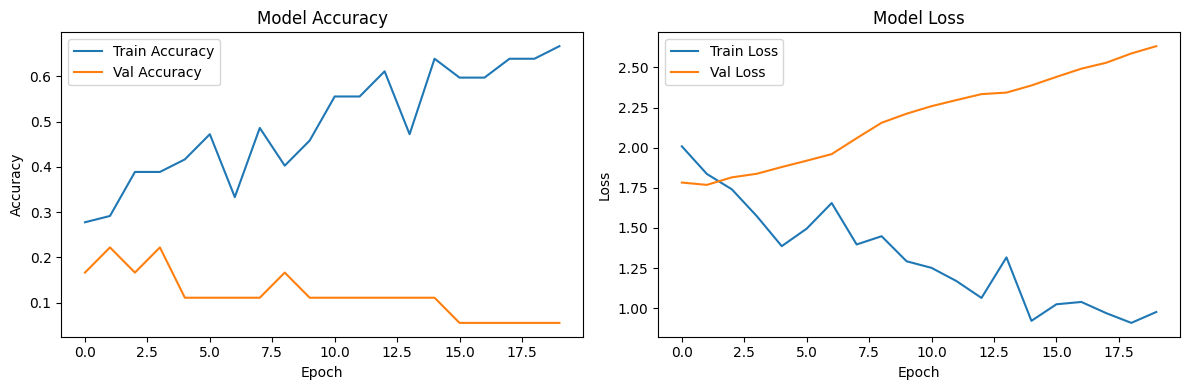

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

### conclusion for Task 1:</br>
</br>
The improved CNN model was successfully built using data augmentation, batch normalization, and dropout. The training accuracy increased over epochs and training loss decreased, showing that the model learned the training data. However, validation accuracy remained very low and validation loss kept increasing. This indicates overfitting, likely because the dataset is very small. So, although the deeper CNN learned the training set better, it did not generalize well to unseen validation data.


### Task 2: load train/validation datasets for VGG16

In [18]:
import tensorflow as tf
from tensorflow import keras

train_dir = "/content/drive/MyDrive/Week - 6/FruitinAmazon/train"

img_height, img_width = 224, 224
batch_size = 32

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.


In [19]:
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 224, 224, 3)
Labels shape: (32,)


load VGG16 and freeze the base model

In [20]:
from tensorflow.keras.applications import VGG16

input_shape = (224, 224, 3)

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=input_shape
)

for layer in base_model.layers:
    layer.trainable = False

print("Base model loaded.")
print("Trainable layers in base model:", sum(layer.trainable for layer in base_model.layers))
print("Total layers in base model:", len(base_model.layers))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model loaded.
Trainable layers in base model: 0
Total layers in base model: 19


add custom classification layers and build final model

In [21]:
from tensorflow.keras import layers, Model

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(1024, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(6, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │         6,150 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,246,150 (58.16 MB)

 Trainable params: 531,462 (2.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

apply VGG16 preprocessing to train and validation datasets

In [22]:
from tensorflow.keras.applications.vgg16 import preprocess_input

train_ds_vgg = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds_vgg = val_ds.map(lambda x, y: (preprocess_input(x), y))

print("VGG16 preprocessing applied.")

VGG16 preprocessing applied.


In [23]:
for images, labels in train_ds_vgg.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 224, 224, 3)
Labels shape: (32,)


train the transfer learning model

In [24]:
history_vgg = model.fit(
    train_ds_vgg,
    validation_data=val_ds_vgg,
    epochs=20
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 39s 13s/step - accuracy: 0.2639 - loss: 5.7733 - val_accuracy: 0.4444 - val_loss: 4.7371
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 14s/step - accuracy: 0.7222 - loss: 2.0266 - val_accuracy: 0.4444 - val_loss: 5.7978
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 35s 11s/step - accuracy: 0.8472 - loss: 1.3908 - val_accuracy: 0.4444 - val_loss: 4.6064
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 38s 13s/step - accuracy: 0.9167 - loss: 0.4834 - val_accuracy: 0.5000 - val_loss: 2.3936
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 35s 11s/step - accuracy: 0.9444 - loss: 0.1527 - val_accuracy: 0.6111 - val_loss: 2.3925
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 11s/step - accuracy: 1.0000 - loss: 0.0045 - val_accuracy: 0.6667 - val_loss: 3.2918
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 34s 11s/step - accuracy: 0.9444 - loss: 0.1554 - val_accuracy: 0.6667 - val_loss: 3.6512
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 34s 11s/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.6667 - val_loss: 3.1977


create test dataset

In [25]:
test_dir = "/content/drive/MyDrive/Week - 6/FruitinAmazon/test"

test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

class_names = test_ds.class_names

print("Class names:", class_names)

Found 30 files belonging to 6 classes.
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


preprocess for VGG16

In [26]:
from tensorflow.keras.applications.vgg16 import preprocess_input

test_ds_vgg = test_ds.map(lambda x, y: (preprocess_input(x), y))
print("Test preprocessing done.")

Test preprocessing done.


evaluate on test set

In [27]:
test_loss, test_accuracy = model.evaluate(test_ds_vgg, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 1.7102
Test Accuracy: 0.9000


generate inference output

In [28]:
import numpy as np

predictions = model.predict(test_ds_vgg, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.concatenate([y for x, y in test_ds_vgg], axis=0)

print("Predicted labels for first 10 images:", predicted_labels[:10])
print("True labels for first 10 images:     ", true_labels[:10])

Predicted labels for first 10 images: [0 0 0 1 0 1 1 1 1 1]
True labels for first 10 images:      [0 0 0 0 0 1 1 1 1 1]


classification report

In [29]:
from sklearn.metrics import classification_report
import numpy as np

true_labels = []
predicted_labels = []

for images, labels in test_ds_vgg:
    preds = model.predict(images, verbose=0)
    predicted_labels.extend(np.argmax(preds, axis=1))
    true_labels.extend(labels.numpy())

true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

report = classification_report(
    true_labels,
    predicted_labels,
    target_names=class_names,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

        acai       0.67      0.80      0.73         5
     cupuacu       0.83      1.00      0.91         5
    graviola       1.00      1.00      1.00         5
     guarana       1.00      1.00      1.00         5
     pupunha       1.00      1.00      1.00         5
      tucuma       1.00      0.60      0.75         5

    accuracy                           0.90        30
   macro avg       0.92      0.90      0.90        30
weighted avg       0.92      0.90      0.90        30



### Conclusion for Task 2

VGG16 performed much better than the CNN trained from scratch. It achieved higher validation performance and 90% test accuracy, showing that transfer learning works well for this small fruit dataset.

### Direct comparison: Task 1 vs Task 2

The CNN from scratch overfit the training data and gave poor validation results. The VGG16 model generalized much better, reaching 77.78% validation accuracy and 90% test accuracy. So, transfer learning clearly performed better than training from scratch.